# EarthCARE: Access and Visualize

Authors: Harshini Girish (UAH),Rajat Shinde (UAH),Alex Mandel (Development Seed),Saskia Brose (ESA)

Date: October 15, 2025

Description: This notebook shows a fast EarthCARE workflow on ESA MAAP: connect to the STAC catalogue, filter by product (e.g., MSI/CPR) and AOI/time, and list matching items. We preview each granule via quicklook images to sanity-check coverage without downloading data.Then we pick the HDF5 asset (`h5_url`), authenticate with an EO Sign-In token, and stream it over HTTPS using fsspec + xarray.Finally, we visualize key variables directly from the streamed dataset, enabling quick QA and analysis with no bulk downloads.



## About the Data

**EarthCARE**

EarthCARE (ESA/JAXA, launched 2024) studies how clouds and aerosols interact with radiation to improve weather and climate models. It flies four co-aligned instruments: ATLID (lidar), CPR (Cloud Profiling Radar), MSI (Multi-Spectral Imager), and BBR (BroadBand Radiometer). Together they provide global coverage with vertical profiles, cloud/aerosol properties, and top-of-atmosphere radiative fluxes from a sun-synchronous orbit.

**MSI COP 2A** 

MSI COP 2A is an MSI Level-2A product that retrieves cloud optical thickness, effective radius/particle size, and derived fields such as cloud water path, plus ancillary flags/quality layers. Data are organized in along-track frames and published per granule with handy quicklook JPEGs and a main HDF5 science file (often enclosure_1) for analysis. Typical uses: rapid cloud screening, scene classification, and radiative studies—often paired with CPR/ATLID for vertical context and BBR for flux closure.


Source:[EarthCARE mission](https://earth.esa.int/eogateway/missions/earthcare)


## Run this notebook
To access and run this tutorial within MAAP’s Algorithm Development Environment (ADE), please refer to the [Getting started with the MAAP](#) section of our documentation.

**Disclaimer**: It is highly recommended to run this tutorial within MAAP’s ADE, which already includes packages specific to MAAP, such as maap-py. Running the tutorial outside of the MAAP ADE may lead to errors.


## Importing Packages

In [1]:
import os
import stat
import getpass
from pathlib import Path
from pystac_client import Client
import fsspec
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from tqdm import tqdm
import requests


## Connect to ESA MAAP STAC

Opens the ESA MAAP catalogue endpoint  and creates a client handle.


In [2]:
catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'
catalog = Client.open(catalog_url)

## Select collection & run filtered STAC search
Choose one `EarthCARE _MAAP`collection (e.g., EarthCAREL2Validated_MAAP) to scope queries and keep searches fast; swap to L1/L2 variants as needed. Run a GET STAC Filter for `productType='MSI_COP_2A'` and `frame='E'` within your bbox, with `max_items=5`, then print both the returned page size and total matched count.

Refer [EarthCARE Documentation](https://earth.esa.int/eogateway/missions/earthcare)

In [3]:
# Select one collection
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']

In [4]:
search = catalog.search(
    collections=EC_COLLECTION, 
    filter="productType = 'MSI_COP_2A' and frame = 'E' ", # Filter by product type
    bbox = [0, -20, 10, -10],
    #datetime = ['2025-06-06T00:00:00Z', None] 
    method = 'GET', 
    max_items=5  # Adjust as needed, given the large amount of products it is recommended to set a limit if especially if you display results in pandas dataframe or similiar
)

items = list(search.items())
print(f"Accessing {len(items)} items (limited by max_items).")
print(f"{search.matched()} items found that matched the query.")

Accessing 5 items (limited by max_items).
349 items found that matched the query.


## Inspect matched item
Selects the first item from the filtered results and prints its ID so we know exactly which granule we’re working with. Then lists all asset keys on that item to choose the right file for preview or download.

In [5]:
# Access the first item only
item = items[0]

print(f"Item 0 — ID: {item.id if hasattr(item, 'id') else item.get('id')}")

# If item is a pystac.Item
try:
    assets = item.assets
except AttributeError:
    # If item is a dict
    assets = item.get("assets", {})

if assets:
    print("  Available asset keys:")
    for key in assets.keys():
        print("   -", key)
else:
    print("  No assets found for this item.")

Item 0 — ID: ECA_EXAB_MSI_COP_2A_20250201T133901Z_20250201T151219Z_03868E
  Available asset keys:
   - thumbnail
   - enclosure_1
   - product
   - enclosure_2
   - metadata_ogc_10_157r4
   - metadata_ogc_17_003r2
   - metadata_iso_19139
   - quicklook


## Build asset table
Converts the `STAC ItemCollection` to a dict and flattens features with pd.json_normalize, selecting just IDs, product type, timestamps, and key asset HREFs. Renames columns to readable labels and sorts by id for easy scanning.

In [6]:
# Using Pandas dataframes for ease of use. 
data = search.item_collection_as_dict()

df = pd.json_normalize(data, record_path=['features'])[
    [
        "id",
        "properties.product:type",                
        "properties.updated",                     
        "assets.product.href",
        "assets.quicklook.href",
        "assets.enclosure_1.href",
        "assets.enclosure_2.href",
    ]
]

# Renaming the assets for 
df.rename(columns={
    'properties.product:type': 'product_type',
    'properties.updated': 'last_modified',
    'assets.product.href': 'Zipped Product',
    'assets.quicklook.href': 'quicklook_url',
    'assets.enclosure_1.href': 'h5_url',
    'assets.enclosure_2.href': 'HDR_url',
}, inplace=True)

df.sort_values(by='id', ascending=True, inplace=True)
print(f"Asset table: {len(df):,} rows × {len(df.columns)} columns")
display(df.head(10))  # increase/decrease as you like

Asset table: 5 rows × 7 columns


,id,product_type,last_modified,Zipped Product,quicklook_url,h5_url,HDR_url
0,ECA_EXAB_MSI_COP_2A_20250201T133901Z_20250201T...,MSI_COP_2A,2025-10-07T01:39:45Z,https://catalog.maap.eo.esa.int/data/zipper/ea...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
2,ECA_EXAB_MSI_COP_2A_20250311T131225Z_20250311T...,MSI_COP_2A,2025-10-07T02:06:39Z,https://catalog.maap.eo.esa.int/data/zipper/ea...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
3,ECA_EXAB_MSI_COP_2A_20250314T151444Z_20250314T...,MSI_COP_2A,2025-10-07T02:08:54Z,https://catalog.maap.eo.esa.int/data/zipper/ea...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
4,ECA_EXAB_MSI_COP_2A_20250316T150330Z_20250316T...,MSI_COP_2A,2025-10-07T02:10:21Z,https://catalog.maap.eo.esa.int/data/zipper/ea...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
1,ECA_EXAB_MSI_COP_2A_20250325T132630Z_20250325T...,MSI_COP_2A,2025-10-07T02:16:50Z,https://catalog.maap.eo.esa.int/data/zipper/ea...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...


**Note** For some JAXA-processed Level-2 products (e.g., AC__CLP_2B, ATL_CLA_2A), the `HDF5` product and its header are swapped between `enclosure_1` and `enclosure_2`. The table below normalizes this by detecting file endings so that h5_url always points to the `.h5` file and `HDR_url` to the `.HDR`, regardless of which enclosure contains them.

## Choose an item and plot

Select a row from the asset table (by index) and grab its quicklook_url so you can visually verify the granule without any heavy download. Rendering the JPEG inline provides a fast QA check (correct product, time window, and coverage) before streaming the .h5 data.

In [7]:
# Choose the file you want to view/stream/download 

fileno = 2 # Adjust this as desired 
ql_url = df.loc[fileno, "quicklook_url"]

display(Image(url= ql_url))


**Note**: Not all EarthCARE products include a quicklook. When absent, we can use the thumbnail instead—it's the same image at a lower resolution.

## Secure HDF5 access via fsspec

## Getting the Token from the ESA MAAP portal

This explains how to retrieve a short-lived access token from the ESA MAAP portal using your browser and NASA EDL login.

**Prerequisites**  
- An active ESA MAAP portal account with access initialized.  
- OAuth2 client credentials for your ESA realm.  
- Python packages: `requests`, `rasterio`, `numpy`, `matplotlib` (optional: `pystac-client`, `stackstac`).  

Open the token page in your browser:
**https://portal.maap.eo.esa.int/ini/services/auth/token/**

**Steps**
1. Navigate to the URL above.  
2. Choose **NASA Earthdata Login (EDL)** when prompted and authorize access.  
3. After successful authorization you will see a **token page** showing your short‑lived access token string.

**Copy the token value** from the token page for use in the next cell.

**Notes**
- Tokens are short‑lived. If you see **401 Unauthorized** later, refresh the token using the same URL and update the value in the notebook.
- Treat tokens as secrets. Do not commit them to version control or share publicly.

Reference: [ESA CCI Biomass V5.01](https://docs.maap-project.org/en/latest/science/ESA_CCI/ESA_CCI_V5_Token_Access.html)

Now we paste the token we got from the portal and save it to a file so it can be used later in the notebook.

In [10]:
# Path: ~/.config/esa_maap/token
TOKEN_FILE = pathlib.Path.home() / ".config" / "esa_maap" / "toknumber"
TOKEN_FILE.parent.mkdir(parents=True, exist_ok=True)

if not TOKEN_FILE.exists():
    tok = getpass.getpass("Paste ESA portal token (hidden): ").strip()
    if not tok:
        raise ValueError("Empty token.")
    TOKEN_FILE.write_text(tok, encoding="utf-8")
    TOKEN_FILE.chmod(stat.S_IRUSR | stat.S_IWUSR)  # mode 600

# permissions sanity
st = TOKEN_FILE.stat()
if (st.st_mode & 0o777) != 0o600:
    raise PermissionError(f"{TOKEN_FILE} must have mode 600. Fix: chmod 600 {TOKEN_FILE}")

ESA_TOKEN = TOKEN_FILE.read_text(encoding="utf-8").strip()
headers   = {"Authorization": f"Bearer {ESA_TOKEN}"}
print("Token loaded from:", TOKEN_FILE)


Token loaded from: /projects/.config/esa_maap/toknumber


## Select the HDF5 asset URL
Picks the chosen row from the assets table and extracts its h5_url.


In [11]:
enclosures = ["enclosure_1", "enclosure_2"]
ds_url = None


try:
    for enc in enclosures:
        asset = getattr(it, "assets", {}).get(enc)
        if asset and getattr(asset, "href", None) and asset.href.lower().endswith(".h5"):
            ds_url = asset.href
            print(f"Found .h5 file in {enc}: {ds_url}")
            break
except NameError:
   
    pass


if not ds_url:
    if "h5_url" in df.columns:
        cand = df.loc[fileno, "h5_url"]
        if isinstance(cand, str) and cand.lower().endswith(".h5"):
            ds_url = cand
            print(f"Falling back to df['h5_url']: {ds_url}")


if not ds_url:
    raise FileNotFoundError("No .h5 file found via enclosure_1/enclosure_2 or df['h5_url'].")


print("Using HDF5 URL:", ds_url)


Falling back to df['h5_url']: https://catalog.maap.eo.esa.int/data/earthcare-pdgs-01/EarthCARE/MSI_COP_2A/AB/2025/03/11/ECA_EXAB_MSI_COP_2A_20250311T131225Z_20250311T144735Z_04459E/ECA_EXAB_MSI_COP_2A_20250311T131225Z_20250311T144735Z_04459E/ECA_EXAB_MSI_COP_2A_20250311T131225Z_20250311T144735Z_04459E.h5
Using HDF5 URL: https://catalog.maap.eo.esa.int/data/earthcare-pdgs-01/EarthCARE/MSI_COP_2A/AB/2025/03/11/ECA_EXAB_MSI_COP_2A_20250311T131225Z_20250311T144735Z_04459E/ECA_EXAB_MSI_COP_2A_20250311T131225Z_20250311T144735Z_04459E/ECA_EXAB_MSI_COP_2A_20250311T131225Z_20250311T144735Z_04459E.h5


## Tune streaming caches
Defines lightweight buffering for remote HDF5 reads: a blockcache in fsspec with 8 MiB blocks and h5py’s raw-data chunk cache set to ~8 MiB. This improves HTTPS streaming and random access while keeping memory use modest; bump the sizes if you see many re-reads.

In [12]:
io_params = {
    "fsspec_params": {
        "cache_type": "blockcache",
        "block_size": 8 * 1024 * 1024
    },
    "h5py_params": {
        "driver_kwds": {
            "rdcc_nbytes": 8 * 1024 * 1024
        }
    }
}

## Stream HDF5 with token and plot variables
Creates an HTTPS fsspec filesystem with your ESA Bearer token, streams the selected .h5 into an xarray Dataset, and then plots two variables side-by-side. Swap variable names (e.g., cloud_water_path, cloud_top_temperature) to what your file exposes, and drop the group argument if that group isn’t present.

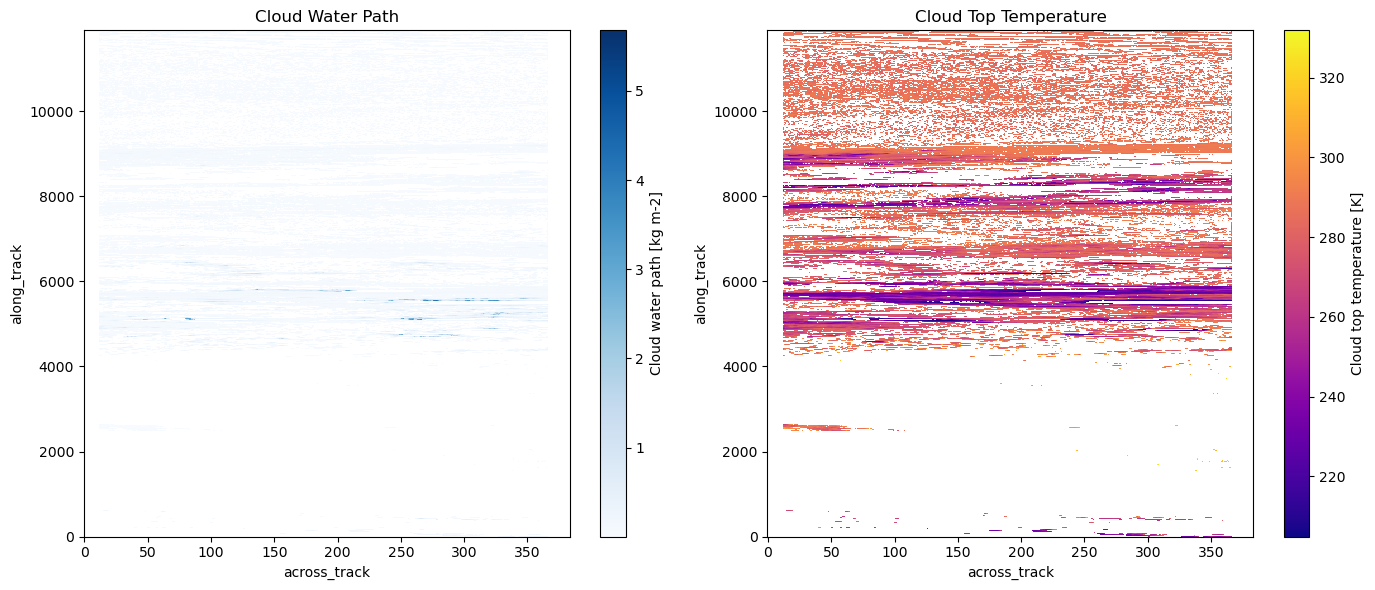

In [13]:
fs = fsspec.filesystem(
    "https", 
    headers={"Authorization": f"Bearer {ESA_TOKEN}"}, 
    **io_params["fsspec_params"]  )

# Open the file and read it into an xarray Dataset
with fs.open(ds_url, "rb") as f:
    ds = xr.open_dataset(f, 
                         engine="h5netcdf", 
                         **io_params["h5py_params"],  
                         group="ScienceData")

    # Do something with ds! Here we plot two variables as an example.
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Cloud Water Path
    ds["cloud_water_path"].plot(ax=axes[0], cmap="Blues")
    axes[0].set_title("Cloud Water Path")

    # Plot Cloud Top Temperature
    ds["cloud_top_temperature"].plot(ax=axes[1], cmap="plasma")
    axes[1].set_title("Cloud Top Temperature")

    plt.tight_layout()
    plt.show()

